In [1]:
import numpy as np # 
from numpy.typing import NDArray 
from numpy import complexfloating as complex_t   
from numpy import floating as real_t                 
import matplotlib.pyplot as plt    
from modules_rel import* 
from modules_for_Bcomplex import* 
from modules_hyper import*

 
# needed natural constants
ij=complex(0.0,1.0)
eV = 27.211384 
atto = 24.18884326505
cpeed=137.035999074 
cm2=0.52917721092**2*100.0 
cross_const=(4.0/3.0)/cpeed*np.pi*cm2
# Nuclear charge 
Zcharge=1.0

# data folder
data_folder = "./output_Leon/"

In [2]:
def get_q_state_r(knots_file, k_order_f, k_order_g, g_grid_file, coeffs_file):

    """
    q state = continuum state
    """

    # knot points
    knots = read_knot_points(knots_file)
    knots_f, knots_g = get_knots_f_g(k_order_f, k_order_g, knots)
    n_knots_f = len(knots_f)
    n_knots_g = len(knots_g)

    # gaussian grid
    g_grid = read_knot_points(g_grid_file) # the function for knots also works for the gaussian grid!

    # q state coefficients
    coeffs = read_q_state_coeffs(coeffs_file)

    # split the q state coefficients for the large and small components
    k_diff_abs = np.abs(k_order_f - k_order_g)
    sep_ind = (len(coeffs) - k_diff_abs) // 2 # separation index
    if k_order_f < k_order_g:
        coeffs_f = coeffs[:sep_ind]
        coeffs_g = coeffs[sep_ind:]
    else:
        coeffs_f = coeffs[:sep_ind + k_diff_abs]
        coeffs_g = coeffs[sep_ind + k_diff_abs:]


    # large component
    q_st_r_f = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_f, g_grid)

    # small component
    q_st_r_g = getfunc_in_r(n_knots_g, k_order_g, knots_g, coeffs_g, g_grid)

    return g_grid, q_st_r_f, q_st_r_g


(-0.001, 0.001)

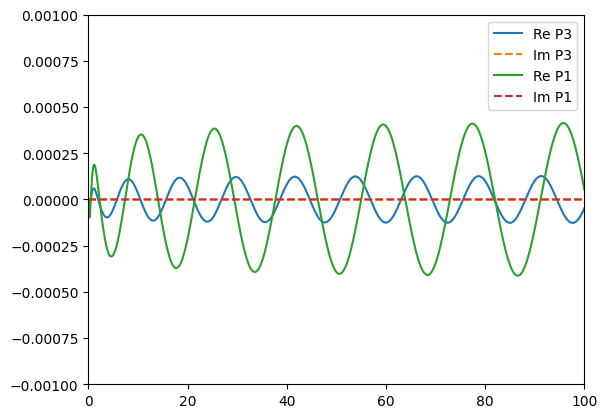

In [3]:
knots_file = data_folder + "grid_vec.dat"
k_order_f = 7
k_order_g = 8
g_grid_file = data_folder + "x_vec.dat"
coeffs_file_p3 = data_folder + "wave_2ph_-2_to_-2_eF1.dat"
coeffs_file_p1 = data_folder + "wave_2ph_-2_to_1_eF1.dat"


g_grid, q_st_r_p3_f, q_st_r_p3_g = get_q_state_r(knots_file, k_order_f, k_order_g, g_grid_file, coeffs_file_p3)
g_grid, q_st_r_p1_f, q_st_r_p1_g = get_q_state_r(knots_file, k_order_f, k_order_g, g_grid_file, coeffs_file_p1)


plt.figure()
plt.plot(np.real(g_grid), np.real(q_st_r_p3_f), label="Re P3")
plt.plot(np.real(g_grid), np.imag(q_st_r_p3_f), "--",  label="Im P3")

plt.plot(np.real(g_grid), np.real(q_st_r_p1_f), label="Re P1")
plt.plot(np.real(g_grid), np.imag(q_st_r_p1_f), "--",  label="Im P1")
plt.legend()
plt.xlim([0, 100])
plt.ylim([-0.001, 0.001])

(-0.1, 0.1)

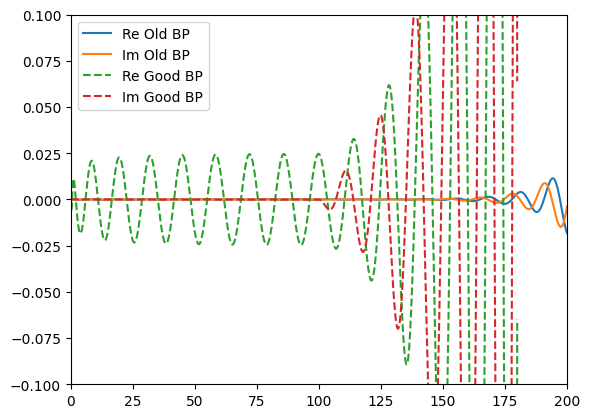

In [4]:
k_order_f = 7
k_order_g = 8

# old bp
knots_file = data_folder + "grid_vec.dat"
g_grid_file = data_folder + "x_vec.dat"
coeffs_file_p3 = data_folder + "wave_2ph_-2_to_-2_eF1.dat"
coeffs_file_p1 = data_folder + "wave_2ph_-2_to_1_eF1.dat"
g_grid, q_st_r_p3_f, q_st_r_p3_g = get_q_state_r(knots_file, k_order_f, k_order_g, g_grid_file, coeffs_file_p3)
g_grid, q_st_r_p1_f, q_st_r_p1_g = get_q_state_r(knots_file, k_order_f, k_order_g, g_grid_file, coeffs_file_p1)

# good bp
knots_file_gb = data_folder + "grid_vec_gb.dat"
g_grid_file_gb = data_folder + "x_vec_gb.dat"
coeffs_file_p3_gb = data_folder + "wave_2ph_-2_to_-2_eF1_gb.dat"
coeffs_file_p1_gb = data_folder + "wave_2ph_-2_to_1_eF1_gb.dat"
g_grid_gb, q_st_r_p3_f_gb, q_st_r_p3_g_gb = get_q_state_r(knots_file_gb, k_order_f, k_order_g, g_grid_file_gb, coeffs_file_p3_gb)
g_grid_gb, q_st_r_p1_f_gb, q_st_r_p1_g_gb = get_q_state_r(knots_file_gb, k_order_f, k_order_g, g_grid_file_gb, coeffs_file_p1_gb)


plt.figure()
plt.plot(np.real(g_grid), np.real(q_st_r_p3_f), label="Re Old BP")
plt.plot(np.real(g_grid), np.imag(q_st_r_p3_f),  label="Im Old BP")

# plt.plot(np.real(g_grid), np.real(q_st_r_p1_f), label="Re P1")
# plt.plot(np.real(g_grid), np.imag(q_st_r_p1_f), "--",  label="Im P1")
plt.plot(np.real(g_grid_gb), np.real(q_st_r_p3_f_gb), "--", label="Re Good BP")
plt.plot(np.real(g_grid_gb), np.imag(q_st_r_p3_f_gb), "--",  label="Im Good BP")

plt.legend()
plt.xlim([0, 200])
plt.ylim([-0.1, 0.1])

In [5]:
np.imag(q_st_r_p3_f_gb)[:20]

array([-9.13114825e-22,  9.78006322e-19,  5.86657771e-18,  1.74214800e-17,
        3.62993355e-17,  6.05638225e-17,  8.62235088e-17,  1.08330998e-16,
        1.22344483e-16,  1.32867497e-16,  1.63586641e-16,  2.20103392e-16,
        3.00650900e-16,  3.97758330e-16,  4.99007156e-16,  5.90641492e-16,
        6.61100917e-16,  7.02617845e-16,  7.21258109e-16,  7.57104999e-16])